Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

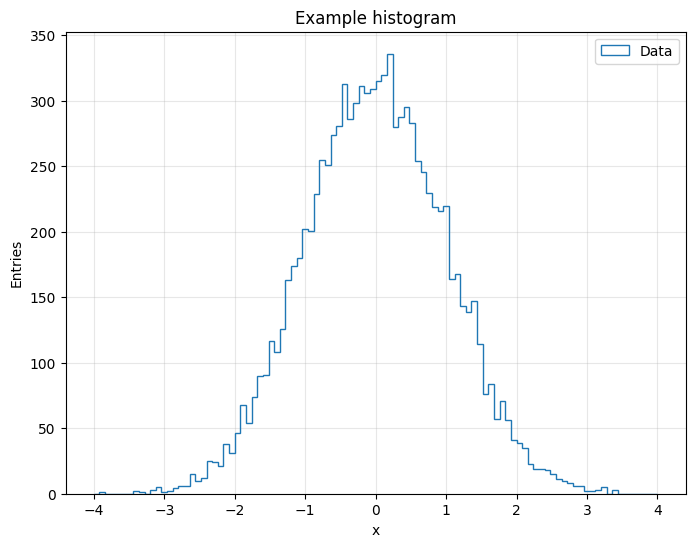

In [1]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [3]:
!python -m pip install uproot

  Using cached uproot-5.7.1-py3-none-any.whl.metadata (35 kB)
  Using cached awkward-2.9.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached cramjam-2.11.0-cp313-cp313-win_amd64.whl.metadata (681 bytes)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached awkward_cpp-52-cp313-cp313-win_amd64.whl.metadata (2.1 kB)
Using cached uproot-5.7.1-py3-none-any.whl (393 kB)
Using cached awkward-2.9.0-py3-none-any.whl (919 kB)
Using cached awkward_cpp-52-cp313-cp313-win_amd64.whl (542 kB)
Using cached cramjam-2.11.0-cp313-cp313-win_amd64.whl (1.7 MB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached xxhash-3.6.0-cp313-cp313-win_amd64.whl (31 kB)

   ------ --------------------------------- 1/6 [fsspec]
   ------ --------------------------------- 1/6 [fsspec]
   ------ --------------------------------- 1/6 [fsspec]
   ------ --------------------------------- 1/6 [fsspec]
   ------ --


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!mkdir LHCb_Data && cd LHCb_Data && curl -O http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

A subdirectory or file LHCb_Data already exists.


In [8]:
%cd LHCb_Data
!curl -O "http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root"
!dir

c:\Users\HP\Documents\PRA3024\PRA3024\LHCb_Data


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0  635M    0  8687    0     0  23592      0  7:50:50 --:--:--  7:50:50 23865
  0  635M    0  504k    0     0   400k      0  0:27:05  0:00:01  0:27:04  401k
  0  635M    0  890k    0     0   392k      0  0:27:38  0:00:02  0:27:36  393k
  0  635M    0 1345k    0     0   411k      0  0:26:20  0:00:03  0:26:17  412k
  0  635M    0 1593k    0     0   372k      0  0:29:05  0:00:04  0:29:01  373k
  0  635M    0 1884k    0     0   357k      0  0:30:19  0:00:05  0:30:14  382k
  0  635M    0 2095k    0     0   334k      0  0:32:25  0:00:06  0:32:19  318k
  0  635M    0 2482k    0     0   341k      0  0:31:45  0:00:07  0:31:38  318k
  0  635M    0 2840k    0     0   343k      0  0:31:34  0:00:08  0:31:26  298k
  0  635M    0 3139k    0     0   338k      0  0:32

 Volume in drive C has no label.
 Volume Serial Number is 6A72-EEAF

 Directory of c:\Users\HP\Documents\PRA3024\PRA3024\LHCb_Data

11/02/2026  09:39    <DIR>          .
11/02/2026  09:33    <DIR>          ..
11/02/2026  09:43       666,484,974 B2HHH_MagnetDown.root
               1 File(s)    666,484,974 bytes
               2 Dir(s)  76,854,272,000 bytes free


In [2]:
import uproot

# Open the ROOT file
file = uproot.open("LHCb_Data\B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]
tree.show()

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

px

<>:4: SyntaxWarning: invalid escape sequence '\B'
<>:4: SyntaxWarning: invalid escape sequence '\B'
C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3886429823.py:4: SyntaxWarning: invalid escape sequence '\B'
  file = uproot.open("LHCb_Data\B2HHH_MagnetDown.root")


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
B_FlightDistance     | double                   | AsDtype('>f8')
B_VertexChi2         | double                   | AsDtype('>f8')
H1_PX                | double                   | AsDtype('>f8')
H1_PY                | double                   | AsDtype('>f8')
H1_PZ                | double                   | AsDtype('>f8')
H1_ProbK             | double                   | AsDtype('>f8')
H1_ProbPi            | double                   | AsDtype('>f8')
H1_Charge            | int32_t                  | AsDtype('>i4')
H1_IPChi2            | double                   | AsDtype('>f8')
H1_isMuon            | int32_t                  | AsDtype('>i4')
H2_PX                | double                   | AsDtype('>f8')
H2_PY                | double                   | AsDtype('>f8')
H2_PZ                | double                   | AsDtype(

array([  375.2842054 , -4985.13078543, -1265.45654435, ...,
        2606.91083928,  -294.71098895,   499.04234923], shape=(5135823,))

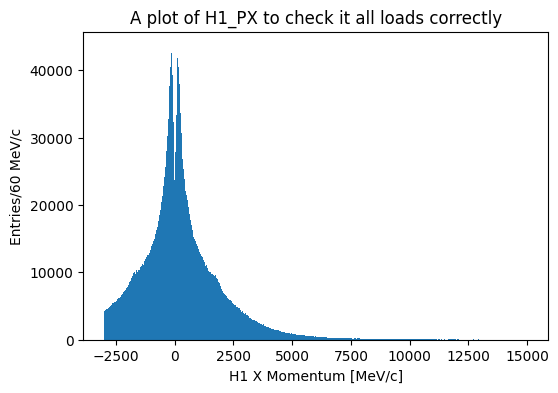

In [3]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(
    px,
    bins=1000,
    range=(-3000, 15000),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_1480\640973536.py:44: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
C:\Users\HP\AppData\Local\Temp\ipykernel_1480\640973536.py:44: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


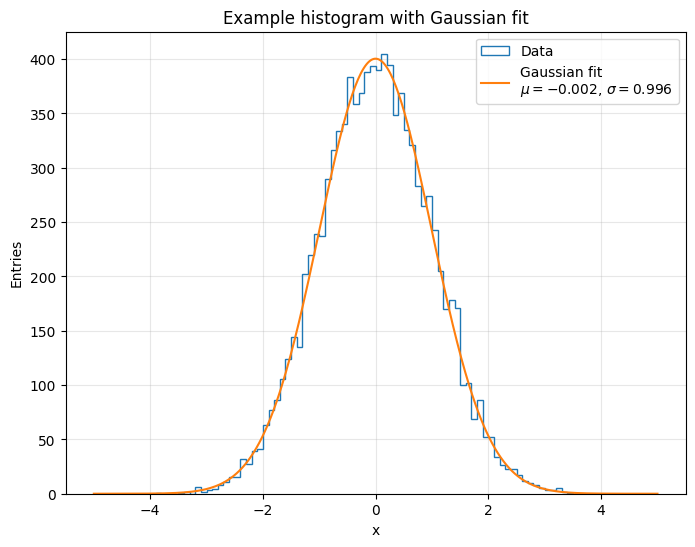

In [4]:
# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -5, 5

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width 


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# abels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()


## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [6]:
#Using Uproot, load your data file and load the variables you think are useful 
# for this analysis - I recommend learning what your data structure is...
# so plotting and calculations becomes easier later.

import uproot

# Open the ROOT file
file = uproot.open("LHCb_Data\B2HHH_MagnetDown.root")

# take PX from H1, H2 and H3 (3 hardons in decay)
# for each particle, calculate its total momentum and make a histogram
# later we will make a comparison plot of total momentum distribution for the 3 particles
# Inside decay tree, Hn_PX, Hn_PY, Hn_PZ are arrays of momentum components from each event

tree = file["DecayTree"]

# H1
px_1 = tree["H1_PX"].array(library="np")
py_1 = tree["H1_PY"].array(library="np")
pz_1 = tree["H1_PZ"].array(library="np")

# H2
px_2 = tree["H2_PX"].array(library="np")
py_2 = tree["H2_PY"].array(library="np")
pz_2 = tree["H2_PZ"].array(library="np")

#H3
px_3 = tree["H3_PX"].array(library="np")
py_3 = tree["H3_PY"].array(library="np")
pz_3 = tree["H3_PZ"].array(library="np")

# calculate total momentum for each particle
p_1 = np.sqrt(px_1**2 + py_1**2 + pz_1**2) # this will create an array of total momentum for H1
p_2 = np.sqrt(px_2**2 + py_2**2 + pz_2**2) # this will create an array of total momentum for H2
p_3 = np.sqrt(px_3**2 + py_3**2 + pz_3**2) # this will create an array of total momentum for H3

<>:8: SyntaxWarning: invalid escape sequence '\B'
<>:8: SyntaxWarning: invalid escape sequence '\B'
C:\Users\HP\AppData\Local\Temp\ipykernel_1480\1929896273.py:8: SyntaxWarning: invalid escape sequence '\B'
  file = uproot.open("LHCb_Data\B2HHH_MagnetDown.root")


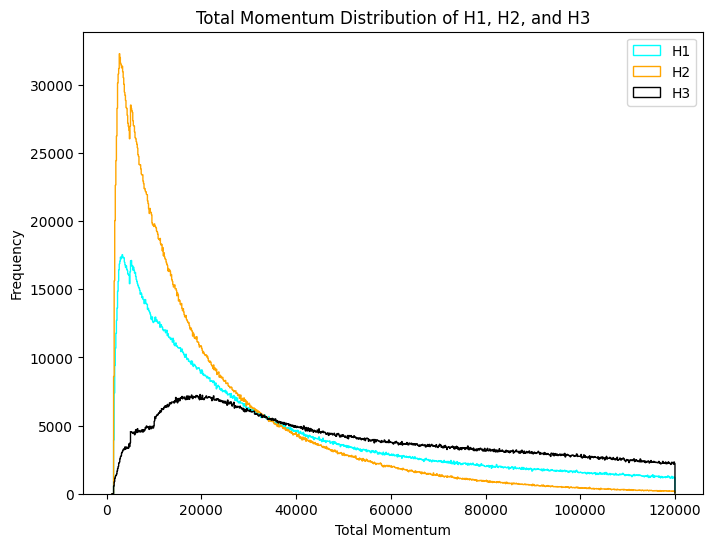

In [7]:
#Here make a plot of the Total momentum of each of the three daughters on one plot
plt.figure(figsize=(8, 6))
plt.hist(p_1, bins=1000, range=(1000, 120000), histtype = "step", color = "cyan", label="H1")
plt.hist(p_2, bins=1000, range=(1000, 120000), histtype= "step", color = "orange", label="H2")
plt.hist(p_3, bins=1000, range=(1000, 120000), histtype = "step", color = "black", label="H3")
plt.xlabel("Total Momentum")
plt.ylabel("Frequency")
plt.title("Total Momentum Distribution of H1, H2, and H3")
plt.legend()
plt.show()

Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

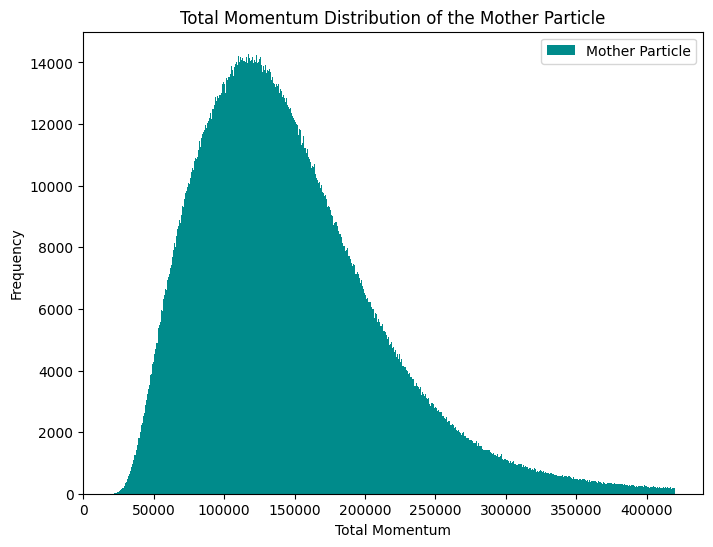

In [8]:
#use the histogram plotting tools, plot the momentum of the mother
# first we have to calculate the momentum of the mother particle
# this we do by summing the momentum components of the daughters
# we then square the sum of each component
# we sum the squares and take the square root to get the total momentum of the mother particle
px_mother = px_1 + px_2 + px_3
py_mother = py_1 + py_2 + py_3
pz_mother = pz_1 + pz_2 + pz_3
p_mother = (px_mother**2 + py_mother**2 + pz_mother**2)**0.5

# plot the total momentum
plt.figure(figsize=(8, 6))
plt.hist(p_mother, bins=1000, range=(20000, 420000), color = "darkcyan", label="Mother Particle")
plt.xlabel("Total Momentum")
plt.ylabel("Frequency")
plt.title("Total Momentum Distribution of the Mother Particle")
plt.legend()
plt.show()

Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [9]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.
tree = file["DecayTree"]

# read the 45th entry from the overall tree
# show the values of all the variables for that entry in a table
import pandas as pd
entry_45 = tree.arrays(library="pd").iloc[44]
entry_45 = entry_45.reset_index() # reset the index cause it is currently the variable names
entry_45.columns = ["Variable", "Value"] 
print(entry_45)

            Variable         Value
0   B_FlightDistance      5.333713
1       B_VertexChi2      6.083737
2              H1_PX  -1634.778091
3              H1_PY    838.662567
4              H1_PZ  15416.880380
5           H1_ProbK      0.002000
6          H1_ProbPi      0.949091
7          H1_Charge      1.000000
8          H1_IPChi2    312.784714
9          H1_isMuon      0.000000
10             H2_PX  -3456.159439
11             H2_PY   -328.792523
12             H2_PZ  21752.773752
13          H2_ProbK      0.003451
14         H2_ProbPi      0.923865
15         H2_Charge     -1.000000
16         H2_IPChi2    301.678913
17         H2_isMuon      0.000000
18             H3_PX  -2892.828671
19             H3_PY  -2105.696831
20             H3_PZ  52930.481698
21          H3_ProbK      0.968910
22         H3_ProbPi      0.083907
23         H3_Charge     -1.000000
24         H3_IPChi2    169.739449
25         H3_isMuon      0.000000


We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

[175445.23603965 419291.17316206 194327.37166602 ...  54356.40059796
 157611.98755452 142225.24157667]


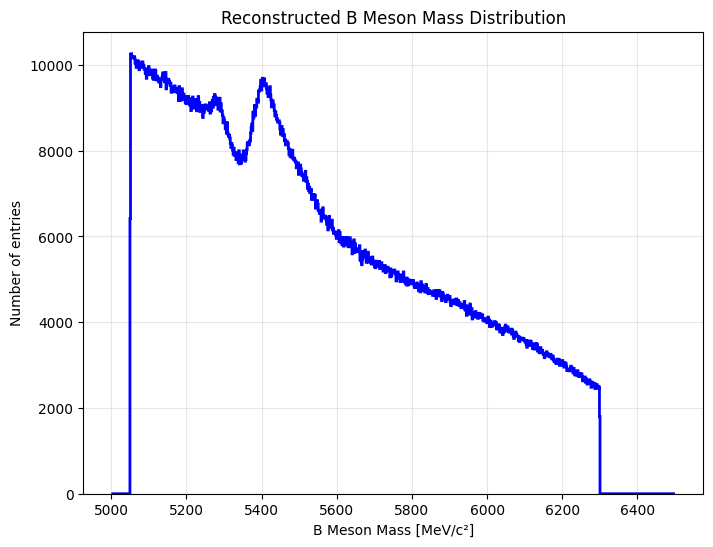

Total events in file: 5135823
Total number of B mesons (charge = ±1): 5135823
Number of B+: 2610178
Number of B-: 2525645
Mean B mass: 5537.42 MeV/c²
Std B mass: 337.63 MeV/c²


In [ ]:
# First find the energy (you might have to do some physics thinking here)
# Get the charges of H1, H2, H3 (H1_Charge, H2_Charge, H3_Charge)
# Add them
# if overall charge is -1 => mother particle is B-
# if overall charge is +1 => mother particle is B+
# take only events where overall charge is +1 or -1 (valid B mesons)
# take the momentum of each of the hadrons
# take the momentum of the mother particle
# we calculate the energy of hadron E_h = sqrt(total_H_momentum^2 + m^2)
# their mass is always fixed m = 493.7
# we add energies of hadrons to get B energy
# with momentum and energy we calculate B mass
# B_Mass = sqrt(energy^2 - momentum^2)

# Get the charges of the three daughter particles
charge_1 = tree["H1_Charge"].array(library="np")
charge_2 = tree["H2_Charge"].array(library="np")
charge_3 = tree["H3_Charge"].array(library="np")

# Calculate total charge to determine if it's B+ or B-
total_charge = charge_1 + charge_2 + charge_3

# Take events where total charge is +1 or -1 (valid B mesons)
B_plus_events = (total_charge == 1)
B_minus_events = (total_charge == -1)
valid_events = B_plus_events | B_minus_events

# Apply filter to momenta to get only valid B meson events
p_1_valid = p_1[valid_events]
p_2_valid = p_2[valid_events]
p_3_valid = p_3[valid_events]
p_mother_valid = p_mother[valid_events]

# Kaon mass in MeV/c^2
m_kaon = 493.7

# Calculate energy for each hadron using E = sqrt(p^2 + m^2)
E_1 = np.sqrt(p_1_valid**2 + m_kaon**2)
E_2 = np.sqrt(p_2_valid**2 + m_kaon**2)
E_3 = np.sqrt(p_3_valid**2 + m_kaon**2)

# Calculate total energy of the B meson (sum of daughter energies)
E_mother = E_1 + E_2 + E_3
print(E_mother)

# Calculate the mass of the B meson using M = sqrt(E^2 - p^2)
B_mass = np.sqrt(E_mother**2 - p_mother_valid**2)

# Plot histogram of the reconstructed B meson mass
plt.figure(figsize=(8, 6))
plt.hist(B_mass, bins=1000, range=(5000, 6500), histtype="step", linewidth=2, color="blue")
plt.xlabel("B Meson Mass [MeV/c²]")
plt.ylabel("Number of entries")
plt.title("Reconstructed B Meson Mass Distribution")
plt.grid(alpha=0.3)
plt.show()

# Print some statistics
print(f"Total events in file: {len(p_1)}")
print(f"Total number of B mesons (charge = ±1): {len(B_mass)}")
print(f"Number of B+: {np.sum(B_plus_events)}")
print(f"Number of B-: {np.sum(B_minus_events)}")
print(f"Mean B mass: {np.mean(B_mass):.2f} MeV/c²")
print(f"Std B mass: {np.std(B_mass):.2f} MeV/c²")

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

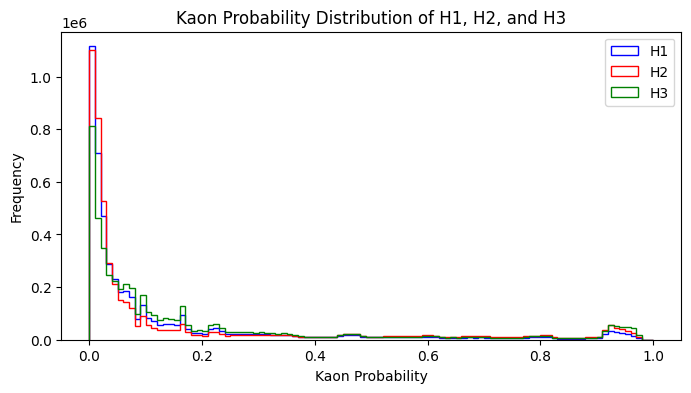

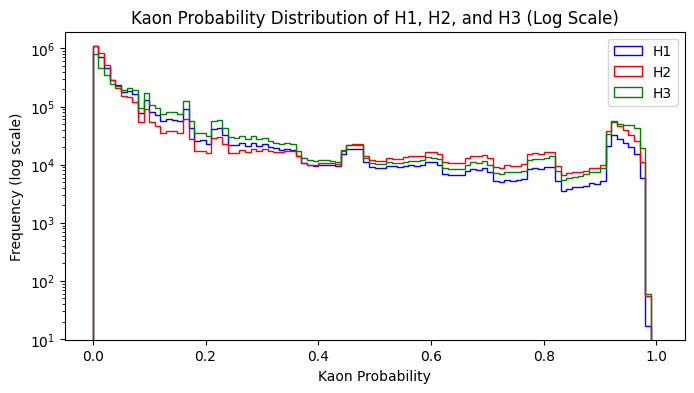

In [18]:
#Make plots of H1/H2/H3 _ProbK on one plot
H1_k_prob = tree["H1_ProbK"].array(library="np")
H2_k_prob = tree["H2_ProbK"].array(library="np")
H3_k_prob = tree["H3_ProbK"].array(library="np")

# do the histograms
plt.figure(figsize=(8, 4))
plt.hist(H1_k_prob, bins=100, range=(0,1), histtype = "step", color = "blue", label="H1")
plt.hist(H2_k_prob, bins=100, range=(0, 1), histtype= "step", color = "red", label="H2")
plt.hist(H3_k_prob, bins=100, range=(0,1), histtype = "step", color = "green", label="H3")
plt.xlabel("Kaon Probability")
plt.ylabel("Frequency")
plt.title("Kaon Probability Distribution of H1, H2, and H3")
plt.legend()
plt.show()

# same histogram but with log scale on y-axis
plt.figure(figsize=(8,4))
plt.hist(H1_k_prob, bins=100, range=(0,1), histtype = "step", color = "blue", label="H1")
plt.hist(H2_k_prob, bins=100, range=(0, 1), histtype= "step", color = "red", label="H2")
plt.hist(H3_k_prob, bins=100, range=(0,1), histtype = "step", color = "green", label="H3")
plt.xlabel("Kaon Probability")
plt.ylabel("Frequency (log scale)")
plt.title("Kaon Probability Distribution of H1, H2, and H3 (Log Scale)")
plt.legend()
plt.yscale("log")  # set y-axis to log scale
plt.show()

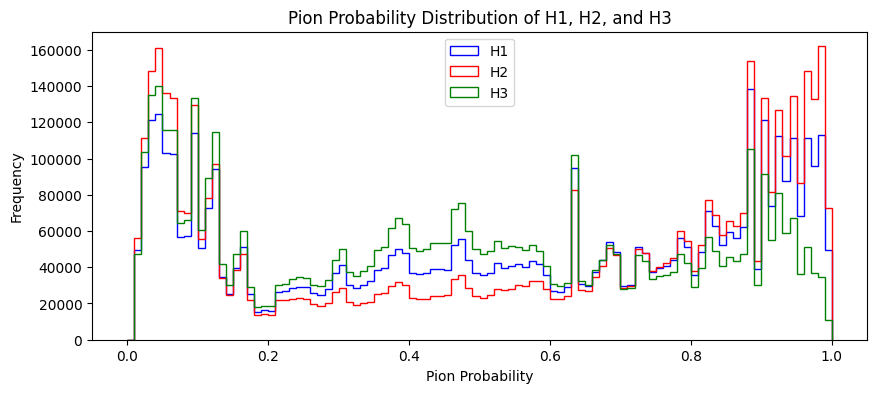

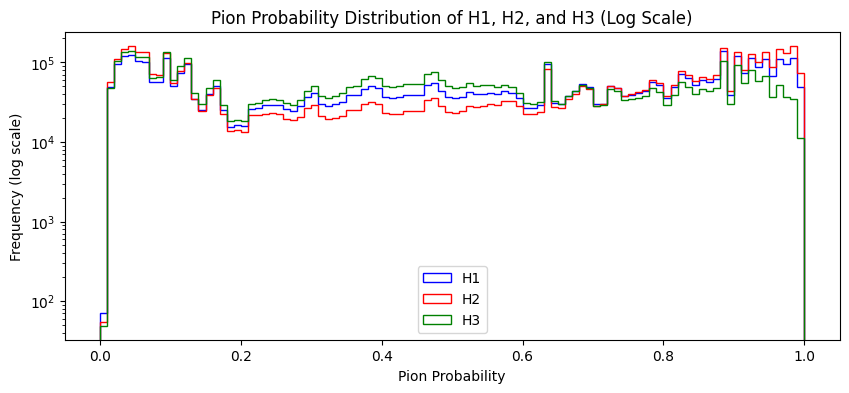

In [19]:
# Do the same for the Probability of being a Pion. Do these distributions match expectations?
#Make plots of H1/H2/H3 _ProbK on one plot
H1_pi_prob = tree["H1_ProbPi"].array(library="np")
H2_pi_prob = tree["H2_ProbPi"].array(library="np")
H3_pi_prob = tree["H3_ProbPi"].array(library="np")

# do the histograms
plt.figure(figsize=(10, 4))
plt.hist(H1_pi_prob, bins=100, range=(0,1), histtype = "step", color = "blue", label="H1")
plt.hist(H2_pi_prob, bins=100, range=(0, 1), histtype= "step", color = "red", label="H2")
plt.hist(H3_pi_prob, bins=100, range=(0,1), histtype = "step", color = "green", label="H3")
plt.xlabel("Pion Probability")
plt.ylabel("Frequency")
plt.title("Pion Probability Distribution of H1, H2, and H3")
plt.legend()
plt.show()

# same histograms but with log scale on y-axis
plt.figure(figsize=(10,4))
plt.hist(H1_pi_prob, bins=100, range=(0,1), histtype = "step", color = "blue", label="H1")
plt.hist(H2_pi_prob, bins=100, range=(0, 1), histtype= "step", color = "red", label="H2")
plt.hist(H3_pi_prob, bins=100, range=(0,1), histtype = "step", color = "green", label="H3")
plt.xlabel("Pion Probability")
plt.ylabel("Frequency (log scale)")
plt.title("Pion Probability Distribution of H1, H2, and H3 (Log Scale)")
plt.legend()
plt.yscale("log")  # set y-axis to log scale
plt.show()

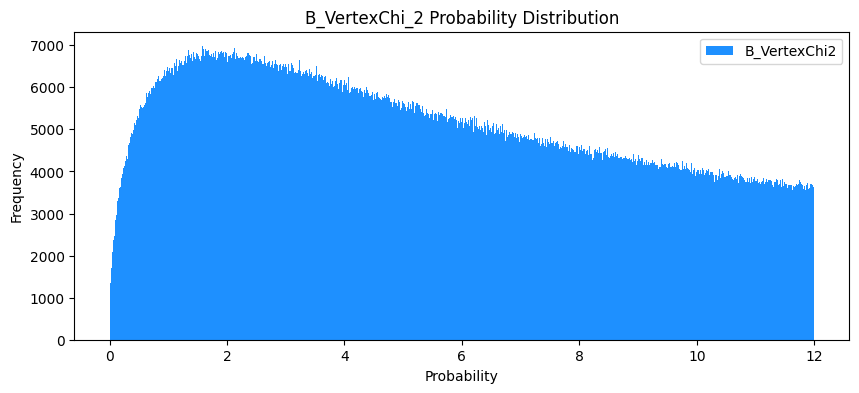

In [ ]:
#For all our particles, make a plot of the B_VertexChi2
# B vertex Chi2 is a measure of how well the decay vertex of the B meson is reconstructed
# lower value of B_VertexChi2 indicated a better fit

B_Vertex_Chi = tree["B_VertexChi2"].array(library="np")

plt.figure(figsize=(10, 4))
plt.hist(B_Vertex_Chi, bins=1000, range=(0,12), color = "dodgerblue", label="B_VertexChi2")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("B_VertexChi_2 Probability Distribution")
plt.legend()
plt.show()

#Feeling ambitious? Maybe make a 2d plot of Kaon and Pion Prob in a 2 dimensional analysis?


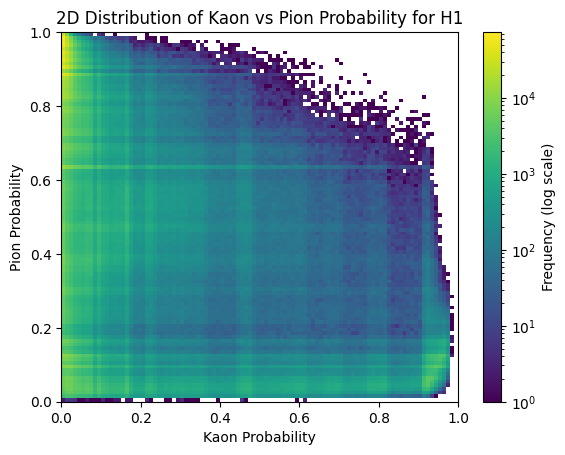

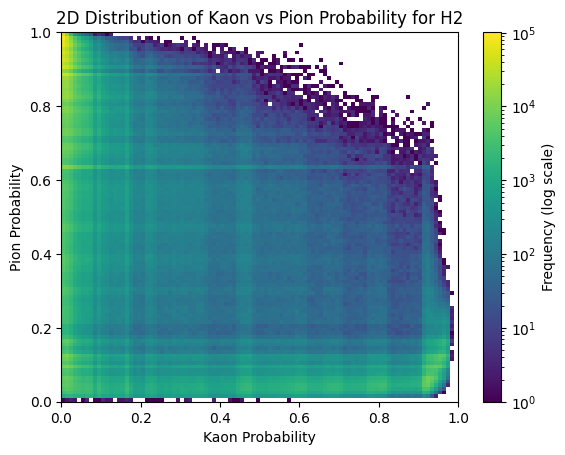

In [25]:
# create a 2D histogram of Kaon vs Pion probability (normalized)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.hist2d(H1_k_prob, H1_pi_prob, bins=100, range=[[0, 1], [0, 1]], cmap="viridis", norm=LogNorm(vmin=1))
plt.xlabel("Kaon Probability")
plt.ylabel("Pion Probability")
plt.title("2D Distribution of Kaon vs Pion Probability for H1")
plt.colorbar(label="Frequency (log scale)")
plt.show()
plt.hist2d(H2_k_prob, H2_pi_prob, bins=100, range=[[0, 1], [0, 1]], cmap="viridis", norm=LogNorm(vmin=1))
plt.xlabel("Kaon Probability")
plt.ylabel("Pion Probability")
plt.title("2D Distribution of Kaon vs Pion Probability for H2")
plt.colorbar(label="Frequency (log scale)")
plt.show()

In [ ]:
# the plots above show us that there is no correlation between two probabilites
# if there is a high probability of being a Kaon, there is a low probability of being a Pion (and vice versa)

Using these plots, we can now make a preselection string. This is a text string that looks like

In [64]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)
selection=("H1_ProbPi<0.6&H2_ProbPi<0.6&H3_ProbPi<0.6&H1_ProbK>0.3&H2_ProbK>0.3&H3_ProbK>0.3")

# apply defined string selection of pion probability > 70% for all 3 hadrons
all_data = tree.arrays(library="pd")

# Apply selection using pandas query
selected_data = all_data.query(selection)

In [65]:
#Look at the total number of entries originally and the new number - how much of your data did you throw away? Was this a good idea? :(
print(f"Total entries before selection: {len(all_data)}")
print(f"Total entries after selection: {len(selected_data)}")
print(f"Total entries removed: {len(all_data) - len(selected_data)}")
percentage_removed = (len(all_data) - len(selected_data)) / len(all_data) * 100
print(f"Percentage of data removed: {percentage_removed:.2f}%")
if percentage_removed > 70:
    print("Maybe too much data removed... Lower your expectations!")

Total entries before selection: 5135823
Total entries after selection: 33617
Total entries removed: 5102206
Percentage of data removed: 99.35%
Maybe too much data removed... Lower your expectations!


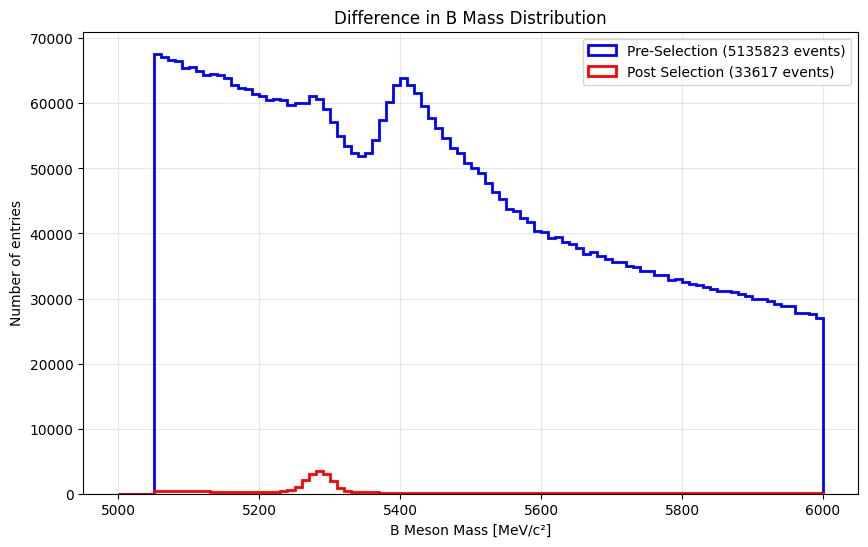

In [66]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?

# first we calculate the B mass for the selected data (post-cuts)
# we repeat the same steps as before when we did it for the overall tree

px_1_sel = selected_data["H1_PX"]
py_1_sel = selected_data["H1_PY"]
pz_1_sel = selected_data["H1_PZ"]

px_2_sel = selected_data["H2_PX"]
py_2_sel = selected_data["H2_PY"]
pz_2_sel = selected_data["H2_PZ"]

px_3_sel = selected_data["H3_PX"]
py_3_sel = selected_data["H3_PY"]
pz_3_sel = selected_data["H3_PZ"]

# Calculate momentum for each daughter 
p_1_sel = np.sqrt(px_1_sel**2 + py_1_sel**2 + pz_1_sel**2) 
p_2_sel = np.sqrt(px_2_sel**2 + py_2_sel**2 + pz_2_sel**2)
p_3_sel = np.sqrt(px_3_sel**2 + py_3_sel**2 + pz_3_sel**2)

# Calculate mother particle momentum (B meson)
px_mother_sel = px_1_sel + px_2_sel + px_3_sel
py_mother_sel = py_1_sel + py_2_sel + py_3_sel
pz_mother_sel = pz_1_sel + pz_2_sel + pz_3_sel
p_mother_sel = np.sqrt(px_mother_sel**2 + py_mother_sel**2 + pz_mother_sel**2)

# Calculate Energy
m_kaon = 493.7 # MeV/c^2
E_1_sel = np.sqrt(p_1_sel**2 + m_kaon**2)
E_2_sel = np.sqrt(p_2_sel**2 + m_kaon**2)
E_3_sel = np.sqrt(p_3_sel**2 + m_kaon**2)
E_mother_sel = E_1_sel + E_2_sel + E_3_sel

# Calculate B Mass
B_mass_selected = np.sqrt(E_mother_sel**2 - p_mother_sel**2)

# Plot the comparison
plt.figure(figsize=(10, 6))

# Plot original mass (valid events only)
plt.hist(B_mass, bins=100, range=(5000, 6000), histtype="step", 
         label=f"Pre-Selection ({len(B_mass)} events)", 
         linewidth=2, color="blue")

# Plot new mass
plt.hist(B_mass_selected, bins=100, range=(5000, 6000), histtype="step", 
         label=f"Post Selection ({len(B_mass_selected)} events)", 
         linewidth=2, color="red")

plt.xlabel("B Meson Mass [MeV/c²]")
plt.ylabel("Number of entries")
plt.title("Difference in B Mass Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




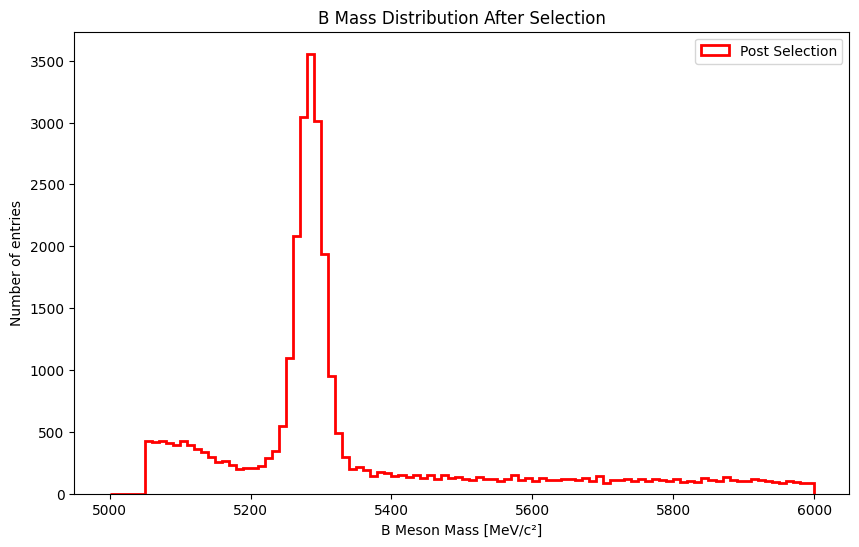

In [67]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!
plt.figure(figsize=(10, 6))
plt.hist(B_mass_selected, bins=100, range=(5000, 6000), histtype="step", 
         label=f"Post Selection", 
         linewidth=2, color="red")
plt.xlabel("B Meson Mass [MeV/c²]")
plt.ylabel("Number of entries")
plt.title("B Mass Distribution After Selection")
plt.legend()


#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [51]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!python -m pip install lmfit

# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)

  Using cached lmfit-1.3.4-py3-none-any.whl.metadata (8.8 kB)
  Using cached asteval-1.0.8-py3-none-any.whl.metadata (6.8 kB)
  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
Using cached lmfit-1.3.4-py3-none-any.whl (97 kB)
Using cached asteval-1.0.8-py3-none-any.whl (22 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
Using cached uncertainties-3.2.3-py3-none-any.whl (60 kB)

   ---------------------------------------- 0/4 [uncertainties]
   ---------------------------------------- 0/4 [uncertainties]
   ---------------------------------------- 0/4 [uncertainties]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   --------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


----------------------------------------
FIT RESULTS:
Mass of B Meson (mu) : 5284.44 MeV/c²
Width of Peak (sigma): 18.19 MeV/c²
----------------------------------------


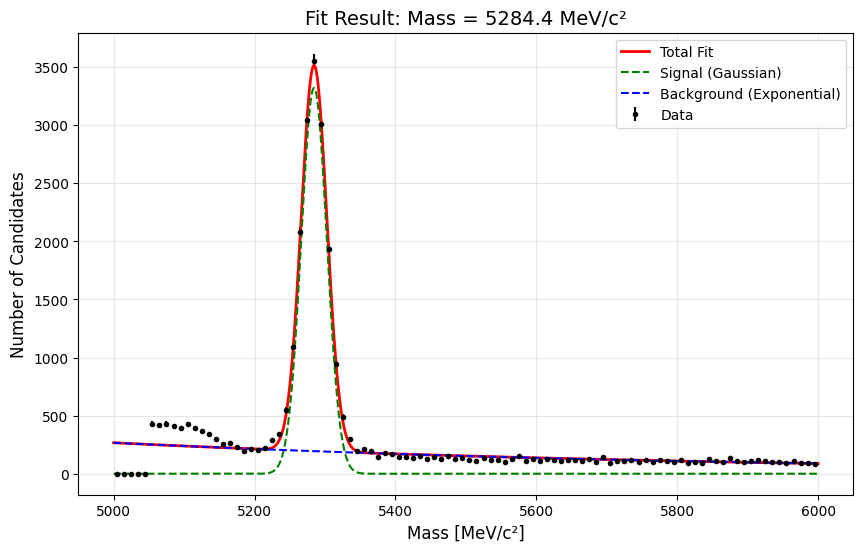

In [69]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.
# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

from scipy.optimize import curve_fit


# The signal is a bell curve (Gaussian)
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((x - mean)**2) / (2 * sigma**2))

# The background is a smooth curve dropping off (Exponential)
def exponential(x, amplitude, decay_rate):
    # We shift x by 5000 to keep numbers manageable for the exponential function
    return amplitude * np.exp(-decay_rate * (x - 5000)) 

# The total model is the sum of both (Signal + Background)
def total_model(x, amp_g, mean, sigma, amp_e, decay):
    return gaussian(x, amp_g, mean, sigma) + exponential(x, amp_e, decay)


# 1. Get your data (ensure it's a numpy array)
# Make sure 'B_mass_selected' is defined from your previous cells!
data = np.array(B_mass_selected)

# 2. Define the range we want to fit (5000 to 6000 MeV)
min_val, max_val = 5000, 6000
n_bins = 100

# 3. Create a histogram from the data to get counts (y) and bin edges (x)
y_counts, x_edges = np.histogram(data, bins=n_bins, range=(min_val, max_val))

# 4. Calculate the center of each bin (this is the x-axis value we fit to)
x_centers = (x_edges[:-1] + x_edges[1:]) / 2


# The computer needs a starting point to find the best fit.

guess_mean = 5280              # We know B meson mass is approx 5280 MeV
guess_sigma = 25               # Guess width is around 25 MeV
guess_amp_g = np.max(y_counts) # Signal height is roughly the peak of the histogram
guess_amp_e = np.max(y_counts)/4 # Background is usually lower than signal peak
guess_decay = 0.002            # Small decay rate for background

# Combine guesses into a list [Amp_Gauss, Mean, Sigma, Amp_Exp, Decay]
initial_guesses = [guess_amp_g, guess_mean, guess_sigma, guess_amp_e, guess_decay]

# -------------------------------------------------------------------
# STEP 4: Perform the Fit!
# -------------------------------------------------------------------

try:
    # curve_fit searches for the best parameters to match our 'total_model' to the data
    popt, pcov = curve_fit(total_model, x_centers, y_counts, p0=initial_guesses)
    
    # Unpack the results into variables
    amp_g_fit, mu_fit, sigma_fit, amp_e_fit, decay_fit = popt
    
    # Print the specific physics results
    print("-" * 40)
    print(f"FIT RESULTS:")
    print(f"Mass of B Meson (mu) : {mu_fit:.2f} MeV/c²")
    print(f"Width of Peak (sigma): {sigma_fit:.2f} MeV/c²")
    print("-" * 40)

except RuntimeError:
    print("Error: The fit could not find a solution. Try changing the initial guesses.")


plt.figure(figsize=(10, 6))

# 1. Plot the actual data as black dots with error bars (standard practice)
# We use sqrt(N) as the error for each bin
y_errors = np.sqrt(y_counts)
plt.errorbar(x_centers, y_counts, yerr=y_errors, fmt='ok', markersize=3, label='Data')

# 2. Create a smooth x-axis for plotting the lines nicely
x_smooth = np.linspace(min_val, max_val, 1000)

# 3. Plot the different components of the fit
# The Total Fit (Red)
plt.plot(x_smooth, total_model(x_smooth, *popt), 'r-', linewidth=2, label='Total Fit')

# The Signal part (Green dashed)
plt.plot(x_smooth, gaussian(x_smooth, amp_g_fit, mu_fit, sigma_fit), 'g--', label='Signal (Gaussian)')

# The Background part (Blue dashed)
plt.plot(x_smooth, exponential(x_smooth, amp_e_fit, decay_fit), 'b--', label='Background (Exponential)')

# Labels and Legend
plt.xlabel("Mass [MeV/c²]", fontsize=12)
plt.ylabel("Number of Candidates", fontsize=12)
plt.title(f"Fit Result: Mass = {mu_fit:.1f} MeV/c²", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\4000032799.py:60: RuntimeWarning: divide by zero encountered in divide
  weights = 1.0 / np.sqrt(y_counts)


Fitting...
[[Model]]
    (Model(crystal_ball, prefix='sig_') + Model(exponential, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16000
    # data points      = 100
    # variables        = 7
    chi-square         = 751.710747
    reduced chi-square = 8.08291126
    Akaike info crit   = 215.718142
    Bayesian info crit = 233.954333
    R-squared          = 0.98289130
##  Warning: uncertainties could not be estimated:
[[Variables]]
    sig_amplitude:  3309.00137 (init = 3556)
    sig_center:     5284.46789 (init = 5279)
    sig_sigma:      18.3009468 (init = 20)
    sig_alpha:      2.10267367 (init = 1.5)
    sig_n:          1.00010300 (init = 2)
    bkg_amplitude:  59284.2601 (init = 889)
    bkg_decay:      919.793836 (init = 1000)


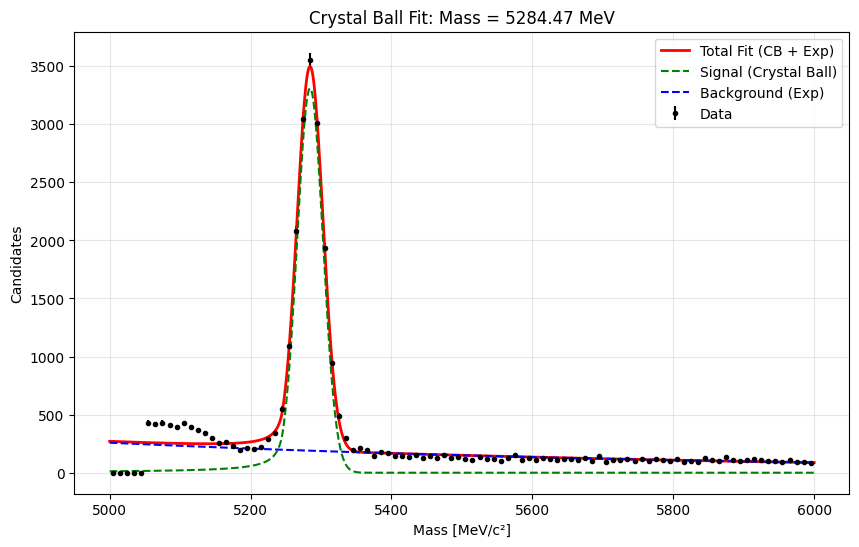

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from lmfit.models import ExponentialModel


# The Crystal Ball function is a Gaussian with a "tail" on one side.
# It's standard for High Energy Physics to account for energy loss.
def crystal_ball(x, amplitude, center, sigma, alpha, n):
    """
    Crystal Ball function:
    x: independent variable
    amplitude: height
    center: mean of the Gaussian core
    sigma: width of the Gaussian core
    alpha: cutoff for the tail
    n: exponent of the tail
    """
    # Normalize inputs
    t = (x - center) / sigma
    
    # Define the two parts of the function
    # Part 1: Gaussian core (if t > -alpha)
    # Part 2: Power law tail (if t <= -alpha)
    
    # We use np.where to switch between the two formulas
    
    # Calculate A and B constants for continuity
    A = (n / np.abs(alpha))**n * np.exp(-0.5 * np.abs(alpha)**2)
    B = (n / np.abs(alpha)) - np.abs(alpha)
    
    # The condition
    cond = t > -alpha
    
    # The result array
    result = np.zeros_like(x)
    
    # Gaussian part
    result[cond] = np.exp(-0.5 * t[cond]**2)
    
    # Tail part
    result[~cond] = A * (B - t[~cond])**(-n)
    
    return amplitude * result



# Use your B_mass_selected variable
data = np.array(B_mass_selected)

# Histogram settings
min_val, max_val = 5000, 6000
n_bins = 100

# Get counts (y) and bin centers (x)
y_counts, x_edges = np.histogram(data, bins=n_bins, range=(min_val, max_val))
x_centers = (x_edges[:-1] + x_edges[1:]) / 2

# Error bars (sqrt(N))
weights = 1.0 / np.sqrt(y_counts)
weights[y_counts == 0] = 0  # Handle empty bins



# Create the signal model from our custom function
signal_model = Model(crystal_ball, prefix="sig_")

# Create the background model from built-in Exponential
bkg_model = ExponentialModel(prefix="bkg_")

# Combine them!
total_model = signal_model + bkg_model



params = total_model.make_params()

# Signal Guesses
params['sig_center'].set(value=5279, min=5200, max=5350)  # B mass
params['sig_sigma'].set(value=20, min=5, max=50)          # Width
params['sig_amplitude'].set(value=np.max(y_counts), min=0) # Height
params['sig_alpha'].set(value=1.5, min=0.1, max=5)        # Tail start (standard guess)
params['sig_n'].set(value=2, min=1, max=10)               # Tail order (standard guess)

# Background Guesses
# Note: lmfit Exponential is amplitude * exp(-x/decay), slightly different from numpy exp
params['bkg_amplitude'].set(value=np.max(y_counts)/4, min=0)
params['bkg_decay'].set(value=1000, min=100) # large value because Mass is ~5000


print("Fitting...")
# weights=weights handles errors properly
result = total_model.fit(y_counts, params, x=x_centers, weights=weights)

# Print report
print(result.fit_report())



plt.figure(figsize=(10, 6))

# Plot Data
plt.errorbar(x_centers, y_counts, yerr=np.sqrt(y_counts), fmt='ko', markersize=3, label='Data')

# Plot Best Fit Line
x_smooth = np.linspace(min_val, max_val, 1000)
plt.plot(x_smooth, result.eval(x=x_smooth), 'r-', linewidth=2, label='Total Fit (CB + Exp)')

# Plot Components (we have to evaluate them separately using the best parameters)
comps = result.eval_components(x=x_smooth)
plt.plot(x_smooth, comps['sig_'], 'g--', label='Signal (Crystal Ball)')
plt.plot(x_smooth, comps['bkg_'], 'b--', label='Background (Exp)')

plt.xlabel('Mass [MeV/c²]')
plt.ylabel('Candidates')
plt.title(f"Crystal Ball Fit: Mass = {result.params['sig_center'].value:.2f} MeV")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [72]:
#find the area under your curve(s)! maybe make a pretty little table...

from scipy.integrate import quad

# Get the best-fit parameters for the signal only
amp = result.params['sig_amplitude'].value
center = result.params['sig_center'].value
sigma = result.params['sig_sigma'].value
alpha = result.params['sig_alpha'].value
n_val = result.params['sig_n'].value

# Define a helper function for integration
def signal_function(x):
    # Ensure x is an array so the crystal_ball indexing works
    x_array = np.atleast_1d(x)
    val = crystal_ball(x_array, amp, center, sigma, alpha, n_val)
    # If original input was a float, return a float (quad expects this)
    if np.isscalar(x): 
        return float(val)
    return val

# Perform the integration over the full range
integral_val, integral_err = quad(signal_function, min_val, max_val)

# Convert Integral to Number of Events
bin_width = (max_val - min_val) / n_bins
n_signal_events = integral_val / bin_width
n_signal_err = integral_err / bin_width

# Print the results
print(f"CALCULATED YIELD:")
print(f"Bin Width              : {bin_width:.2f} MeV")
print(f"Integral Area          : {integral_val:.2f}")
print(f"Number of Signal Events: {n_signal_events:.0f} ± {n_signal_err:.4f} (integration error)")

CALCULATED YIELD:
Bin Width              : 10.00 MeV
Integral Area          : 159761.61
Number of Signal Events: 15976 ± 0.0000 (integration error)


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\2873852783.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(val)


#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

Fitting B+...


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\2121791204.py:12: RuntimeWarning: divide by zero encountered in divide
  weights = 1.0 / np.sqrt(y_counts)
C:\Users\HP\AppData\Local\Temp\ipykernel_1480\2121791204.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.isscalar(x): return float(val)
C:\Users\HP\AppData\Local\Temp\ipykernel_1480\2121791204.py:12: RuntimeWarning: divide by zero encountered in divide
  weights = 1.0 / np.sqrt(y_counts)


Fitting B-...


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\2121791204.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.isscalar(x): return float(val)



Asymmetry results:
N(B+)     : 8610
N(B-)     : 7354
Asymmetry : -0.0787 ± 0.0079


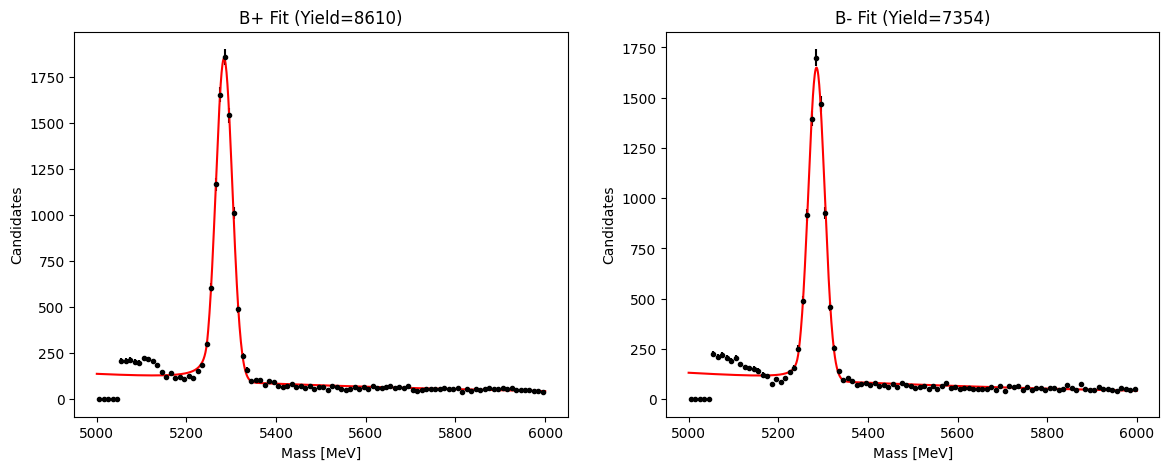

In [73]:
#Here do your calculation of the final result

from scipy.integrate import quad
from lmfit import Model
from lmfit.models import ExponentialModel

# Define helper function to fit data and calculate yield
def get_yield_from_fit(data_array):
    # Create Histogram
    y_counts, x_edges = np.histogram(data_array, bins=100, range=(5000, 6000))
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    weights = 1.0 / np.sqrt(y_counts)
    weights[y_counts == 0] = 0

    # Define Model (Create fresh model instances for each fit)
    sig_mod = Model(crystal_ball, prefix="sig_")
    bkg_mod = ExponentialModel(prefix="bkg_")
    mod = sig_mod + bkg_mod
    
    # Set Parameters
    pars = mod.make_params()
    pars['sig_center'].set(value=5279, min=5250, max=5300)
    pars['sig_sigma'].set(value=20, min=5, max=50)
    pars['sig_amplitude'].set(value=np.max(y_counts), min=0)
    pars['sig_alpha'].set(value=1.5, min=0.1, max=5)
    pars['sig_n'].set(value=2, min=1, max=10)
    pars['bkg_amplitude'].set(value=np.max(y_counts)/4, min=0)
    pars['bkg_decay'].set(value=1000, min=100)

    # Perform Fit
    out = mod.fit(y_counts, pars, x=x_centers, weights=weights)
    
    # Calculate Yield using Integration
    amp = out.params['sig_amplitude'].value
    av = out.params['sig_center'].value 
    sig = out.params['sig_sigma'].value
    al = out.params['sig_alpha'].value
    n_exp = out.params['sig_n'].value
    
    def integ_func(x):
        x_arr = np.atleast_1d(x)
        val = crystal_ball(x_arr, amp, av, sig, al, n_exp)
        if np.isscalar(x): return float(val)
        return val

    integral_val, _ = quad(integ_func, 5000, 6000)
    bin_width = (6000 - 5000) / 100
    yield_val = integral_val / bin_width
    
    return yield_val, out, x_centers, y_counts

# Get charges from our selected dataframe
q1 = selected_data["H1_Charge"].values
q2 = selected_data["H2_Charge"].values
q3 = selected_data["H3_Charge"].values

# Calculate total charge sum (+1 or -1)
total_q = q1 + q2 + q3

# Recalculate B mass for selected data to ensure alignment
sel_px = selected_data["H1_PX"] + selected_data["H2_PX"] + selected_data["H3_PX"]
sel_py = selected_data["H1_PY"] + selected_data["H2_PY"] + selected_data["H3_PY"]
sel_pz = selected_data["H1_PZ"] + selected_data["H2_PZ"] + selected_data["H3_PZ"]
sel_p = np.sqrt(sel_px**2 + sel_py**2 + sel_pz**2)

# Calculate Energy components
m_k = 493.7
sel_E1 = np.sqrt(selected_data["H1_PX"]**2 + selected_data["H1_PY"]**2 + selected_data["H1_PZ"]**2 + m_k**2)
sel_E2 = np.sqrt(selected_data["H2_PX"]**2 + selected_data["H2_PY"]**2 + selected_data["H2_PZ"]**2 + m_k**2)
sel_E3 = np.sqrt(selected_data["H3_PX"]**2 + selected_data["H3_PY"]**2 + selected_data["H3_PZ"]**2 + m_k**2)
sel_E = sel_E1 + sel_E2 + sel_E3

# Calculate Mass
mass_vec = np.sqrt(sel_E**2 - sel_p**2)

# Create masks for B+ and B-
mask_plus = (total_q == 1)
mask_minus = (total_q == -1)

mass_plus = mass_vec[mask_plus]
mass_minus = mass_vec[mask_minus]

# Fit B+ Data
print("Fitting B+...")
N_plus, res_plus, x_p, y_p = get_yield_from_fit(mass_plus)

# Fit B- Data
print("Fitting B-...")
N_minus, res_minus, x_m, y_m = get_yield_from_fit(mass_minus)

# Calculate Asymmetry
N_sum = N_minus + N_plus
N_diff = N_minus - N_plus

A = N_diff / N_sum
sigma_A = np.sqrt((1 - A**2) / N_sum) # Standard error for binomial asymmetry

print(f"\nAsymmetry results:")
print(f"N(B+)     : {N_plus:.0f}")
print(f"N(B-)     : {N_minus:.0f}")
print(f"Asymmetry : {A:.4f} ± {sigma_A:.4f}")

# Plot both fits side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot B+
x_smooth = np.linspace(5000, 6000, 1000)
ax[0].errorbar(x_p, y_p, yerr=np.sqrt(y_p), fmt='k.')
ax[0].plot(x_smooth, res_plus.eval(x=x_smooth), 'r-')
ax[0].set_title(f"B+ Fit (Yield={N_plus:.0f})")
ax[0].set_xlabel("Mass [MeV]")
ax[0].set_ylabel("Candidates")

# Plot B-
ax[1].errorbar(x_m, y_m, yerr=np.sqrt(y_m), fmt='k.')
ax[1].plot(x_smooth, res_minus.eval(x=x_smooth), 'r-')
ax[1].set_title(f"B- Fit (Yield={N_minus:.0f})")
ax[1].set_xlabel("Mass [MeV]")
ax[1].set_ylabel("Candidates")

plt.show()

#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [ ]:
#Define a function to find the invarient mass of two given Kaons

In [ ]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [ ]:
#Make the revised Dalitz plot here for B+ mesons

In [ ]:
#Make the revised Dalitz plot here for B- mesons

In [ ]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)